# Pipeline metagenómico

Este cuaderno toma uno o más `run_accession` de ENA (proyecto [PRJEB11755](https://www.ebi.ac.uk/ena/browser/view/PRJEB11755)),
descarga las lecturas crudas, las procesa hasta obtener contigs ensamblados, y responde:

1. **¿Qué genes de resistencia antimicrobiana (ARG) hay?** — vía [CARD](https://card.mcmaster.ca/) + RGI. Esto es lo único
   que corre automáticamente por cada muestra en la sección 4.
2. **¿A qué especie pertenece cada contig con ARG?** — vía BLAST remoto contra `nt` (NCBI). Manual, sección 3.6.
3. **¿Qué se sabe de esa cepa/especie?** — vía [BacDive](https://bacdive.dsmz.de/). Se moverá a `04_modelo_ml.ipynb`,
   para consultarla solo sobre las especies de los genes que el modelo termine señalando, no por cada muestra aquí.


## 1. Requisitos de cómputo, tiempo y almacenamiento

Mediciones tomadas de una corrida real de este notebook sobre `ERR1135202` (submuestreo de 1M pares de lecturas, `THREADS=8`, en una máquina de 12 hilos / 7.4GB RAM). Sirven como referencia de orden de magnitud, no como garantía: la descarga y el BLAST remoto dependen de la red y de la carga de los servidores de ENA/NCBI. **Desde la sección 3.5, el BLAST remoto y BacDive ya no corren automaticamente por muestra** (ver seccion 3.6) -- el costo por muestra listado abajo excluye esas dos filas para la corrida por defecto.

### Por paso (una muestra)

| Paso | Tiempo medido | Disco (pico) | RAM |
|---|---|---|---|
| CARD: descarga + `rgi load` (una sola vez, no por muestra) | ~1 min (build del índice; la descarga en sí son 4.6MB) | ~90MB (`card.json` 41MB + `localDB/` 49MB) | <1GB |
| Descarga ENA (`raw/`, par de FASTQ completos, **no** submuestreados) | Muy variable con la red; el par completo pesa 3.4GB comprimidos (~47M pares de lecturas) | 3.4GB | mínima (streaming a disco) |
| QC (`fastp`) — corre sobre la muestra **completa**, antes de submuestrear | ~15 min (47M pares, 4.3Gbp, 8 hilos) | +3.6GB (`clean_1/2.fastq.gz`) | ~1-2GB |
| Submuestreo (`seqtk`, a `SUBSAMPLE=1_000_000`) | ~6 min | +480MB (`sub_1/2.fastq`, sin comprimir) | ~1GB |
| Ensamblado (`MEGAHIT`) sobre la submuestra | ~2.6 min (155s, medido en el log de MEGAHIT) | ~92MB (`megahit_out/`) | baja en esta muestra pequeña; crece con `SUBSAMPLE` |
| Predicción de genes (`prodigal`) | ~4 min | ~5.4MB (`genes.faa`+`genes.fna`) | <1GB |
| ARG (`rgi` + DIAMOND contra CARD local) | segundos (~4s medidos, para 8264 genes candidatos) | <1MB | <1GB |
| Limpieza (seccion 3.5) | segundos | libera ~7.4GB (raw/ + intermedios de work/) | mínima |
| *(manual, no automatico) BLAST remoto contra `nt`, 1 consulta secuencial por contig con ARG* | *muy variable: minutos por contig según carga del servidor NCBI; con 8 contigs, del orden de 10-40 min* | *ninguno (todo remoto)* | *mínima* |
| *(manual, no automatico) BacDive, 1 consulta API por especie única detectada* | *segundos por especie* | *ninguno* | *mínima* |

: Tiempo, disco y RAM medidos por paso (muestra `ERR1135202`, submuestreada a 1M pares)

**Total aproximado por muestra (corrida por defecto, sin BLAST/BacDive):** ~30 min de cómputo local (QC + submuestreo + ensamblado + genes + ARG) más el tiempo de descarga, que junto con BLAST remoto (si se corre manualmente despues) son los dos cuellos de botella dominados por red/servidor y no por CPU local.

**Disco por muestra:** pico transitorio de `raw/<run>/` (3.4GB) + `work/<run>/` (~4.1GB de `clean_*`, `sub_*`, `megahit_out/`, genes) + `results/<run>/` (<1MB) ≈ **7.5GB** mientras se procesa, sin contar la base CARD compartida (~90MB, una sola vez). **Desde la seccion 3.5, `procesar_muestra()` borra automaticamente `raw/<run>/` y los intermedios pesados de `work/<run>/` apenas termina esa muestra** -- lo que queda despues es solo `genes.fna`/`genes.faa`/`megahit_out/final.contigs.fa` (~9MB) + `results/<run>/` (<1MB) por muestra.

### Tamaño de las bases de datos de referencia

- **CARD** (la que usa este pipeline): descarga comprimida 4.6MB → `card.json` 41MB → índice local de RGI (`localDB/`, BLAST+DIAMOND) 49MB. Total ≈ 90MB. Trivial para cualquier portátil.
- **CAT_pack/BAT** (clasificación taxonómica local de contigs; se intentó en `02_pipeline_inicial.ipynb` pero la base nunca se descargó — ver el error *"cannot find the taxonomy folder"* en `results/<run>/CAT/out.log`): las bases preconstruidas en `tbb.bio.uu.nl/tina/CAT_pack_prepare/` pesan **~198GB comprimidos** (basada en NCBI `nr`) o **~92GB comprimidos** (basada en GTDB), y CAT recomienda tener ~200GB de RAM disponible para correr contra `nr` con buen rendimiento. Por eso este notebook usa BLAST remoto en su lugar: evita la descarga de cientos de GB a cambio de consultas más lentas y sujetas al límite de tasa de NCBI.
- **NCBI `nt`** (la que se consulta remotamente vía `NCBIWWW.qblast`, sin descargarla): si algún día se quisiera correr localmente, la `nt` completa actual son **~830GB comprimidos** (342 volúmenes), o **~210GB comprimidos** (80 volúmenes) para `core_nt`, el subconjunto curado que NCBI recomienda ahora como alternativa más liviana. Descomprimida más el índice de BLAST ocupa notablemente más que eso.

### Otras fuentes a considerar más adelante

- **ARDB** (`catalog/pig_ardb.annotation.gz`, ya en el repo) — predecesor de CARD, discontinuado desde ~2009; útil solo como referencia cruzada legada del estudio original de PRJEB11755.
- **NR de NCBI** (`catalog/pig_NR_tax.annotation.gz`, ya en el repo) — mismas advertencias de tamaño que `nt` si se usara una copia local completa.

## 2. Configuración, parámetros y utilidades

Comenzamos importando las librerías necesarias, y definir los parámetros de ejecución del pipeline. En la variable ´RUNS´ definimos cuáles muestras de la base de datos de ENA serán descargadas y procesadas por el pipeline. Debido a que este pipeline está diseñado para computadores portátiles comerciales, utilizamos una estrategia de submuestreo para crear muestras aleatorias de un tamaño fijo, debido a que procesar una muestra entera puede ser significativamente intenso para computadores personales. Para el ejemplo de prueba, creamos submuestras de 1 millones de pares de bases.  

In [1]:
import gzip
import hashlib
import re
import shutil
import subprocess
import time
import urllib.error
import urllib.request
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
from Bio import SeqIO
from Bio.Blast import NCBIWWW, NCBIXML
import os

# ---- Muestras a procesar ----
# Un solo run_accession o una lista: el pipeline completo se corre para cada uno.
# Seleccion ampliada a 50 muestras (36 anteriores + 14 nuevas), proporcional a los
# grupos de PRJEB11755 (alias de muestra por granja/cohorte: PIG, EYZ, SYZ, BMZ,
# BHZ, ZXZ, DB), con al menos 1 run por grupo y el resto ponderado por tamano de
# grupo (200/52/38/34/24/22/20 corridas respectivamente; para 50 muestras eso da
# 26/7/5/4/3/3/2, redondeando por resto mas grande). Cada muestra biologica
# tiene en ENA dos corridas: una profunda (~2-5GB, la que usamos) y una companion
# muy chica (~30-70MB, insuficiente para ensamblar); se filtro por tamano (>1GB)
# para no elegir por error la corrida chica. Dentro de cada grupo se prefirieron
# las corridas profundas mas livianas, para controlar el volumen de descarga
# (las mas livianas de PIG/EYZ ya se usaron en rondas anteriores, por eso esta
# ronda pesa mas por muestra: ~4.3-4.4GB en PIG, ~2GB en EYZ/BMZ, ~4.3GB en SYZ,
# ~4.3GB en ZXZ, ~5GB en BHZ).
RUNS = [
    "ERR1135202",  # PIG-028, ya procesada, se omite rapido (idempotente)
    "ERR1135191", "ERR1135194", "ERR1135222", "ERR1135251",  # PIG (4 nuevas)
    "ERR1135438", "ERR1135436",  # EYZ
    "ERR1135451",  # SYZ
    "ERR1135395",  # BMZ
    "ERR1135386",  # BHZ
    "ERR1135463",  # ZXZ
    "ERR1135414",  # DB
    # -- ampliacion a 24 muestras --
    "ERR1135204", "ERR1135195", "ERR1135203", "ERR1135206",
    "ERR1135252", "ERR1135196", "ERR1135205",  # PIG (7 mas, 12 en total)
    "ERR1135434",  # EYZ (3 en total)
    "ERR1135450",  # SYZ (2 en total)
    "ERR1135392",  # BMZ (2 en total)
    "ERR1135381",  # BHZ (2 en total)
    "ERR1135462",  # ZXZ (2 en total)
    # -- ampliacion a 36 muestras --
    "ERR1135199", "ERR1135209", "ERR1135198", "ERR1135208", "ERR1135261", "ERR1135207",
    # PIG (6 mas, 18 en total)
    "ERR1135437", "ERR1135435",  # EYZ (2 mas, 5 en total)
    "ERR1135452", "ERR1135447",  # SYZ (2 mas, 4 en total)
    "ERR1135391",  # BMZ (1 mas, 3 en total)
    "ERR1135412",  # DB (1 mas, 2 en total)
    # -- ampliacion a 50 muestras --
    "ERR1135253", "ERR1135254", "ERR1135238", "ERR1135182",
    "ERR1135210", "ERR1135259", "ERR1135220", "ERR1135264",
    # PIG (8 mas, 26 en total)
    "ERR1135433", "ERR1135428",  # EYZ (2 mas, 7 en total)
    "ERR1135445",  # SYZ (1 mas, 5 en total)
    "ERR1135393",  # BMZ (1 mas, 4 en total)
    "ERR1135384",  # BHZ (1 mas, 3 en total)
    "ERR1135468",  # ZXZ (1 mas, 3 en total)
]

# ---- Parámetros del pipeline ----
SUBSAMPLE = 1_000_000   # nº de pares de lecturas a submuestrear (ensayo rápido; sube o quita el paso para la muestra completa)
THREADS   = 12            # hilos de CPU para fastp / megahit
SEED      = 100          # semilla fija -> submuestreo reproducible
CARD_URL  = "https://card.mcmaster.ca/latest/data"

# NCBI pide un correo real para BLAST remoto (evita bloqueos por uso anónimo)
NCBIWWW.email = "jujgomezru@unal.edu.co"

# Credenciales de BacDive (registro gratuito en https://bacdive.dsmz.de/api/bacdive/registration/register/).
# Se leen de variables de entorno para no dejar contraseñas en el notebook.
# NOTA: BacDive ya no se consulta desde este notebook (ver seccion 3.6) -- se movera
# a 04_modelo_ml.ipynb, para correrla solo sobre los genes que el modelo termine
# senalando, no por cada especie de cada muestra procesada aqui.

BACDIVE_USER     = os.environ.get("BACDIVE_EMAIL", "")
BACDIVE_PASSWORD = os.environ.get("BACDIVE_PASSWORD", "")

Esta función es estética. Ejecutamos cada una de las consultas del pipeline con esta función, para que el Notebook muestre el progreso en vivo de la consulta, asegurando al usuario que la consulta está siendo procesada, o mostrar errores inmediatamente si se presentan.

In [2]:
def sh(cmd, live=False):
    """Ejecuta un comando de shell y aborta si falla.

    Con live=True muestra la salida linea a linea con el tiempo transcurrido (util para
    pasos largos como el ensamblado); si no, la muestra completa al terminar.
    """
    print(f"$ {cmd}" + ("\n" if live else ""))
    if not live:
        r = subprocess.run(cmd, shell=True, text=True,
                           stdout=subprocess.PIPE, stderr=subprocess.STDOUT)
        if r.stdout:
            print(r.stdout)
        if r.returncode != 0:
            raise RuntimeError(f"Fallo (codigo {r.returncode}): {cmd}")
        return r.stdout

    t0 = time.time()
    proc = subprocess.Popen(cmd, shell=True, text=True, bufsize=1,
                            stdout=subprocess.PIPE, stderr=subprocess.STDOUT)
    for line in proc.stdout:
        el = time.time() - t0
        print(f"[{int(el // 60):>2}m{int(el % 60):02d}s] {line}", end="", flush=True)
    proc.wait()
    el = time.time() - t0
    if proc.returncode != 0:
        raise RuntimeError(f"Fallo (codigo {proc.returncode}) tras {int(el)}s: {cmd}")
    print(f"\nCompletado en {int(el // 60)}m{int(el % 60):02d}s")

### Base de datos CARD (una sola vez, compartida por todas las muestras)

Estrategia en cascada: si ya está cargada la usa; si no, reutiliza un `card.json` local; y si tampoco, lo descarga.

In [3]:
def ensure_card_db():
    if Path("localDB/card.json").exists():
        print("CARD ya esta cargada en localDB/")
        return

    if Path("card.json").exists():
        print("Cargando card.json en la raíz")
    elif Path("data/card.json").exists():
        print("Reusar card.json ya existente.")
        sh("cp data/card.json card.json")
    else:
        print("No hay CARD en ningun sitio; descargando...")
        sh(f"wget -q {CARD_URL} -O card_data.tar.bz2")
        sh("tar -xjf card_data.tar.bz2 ./card.json")

    sh("rgi load --card_json card.json --local")
    assert Path("localDB/card.json").exists(), "CARD no quedó cargada; revisa los pasos de arriba."
    print("Base CARD lista en:", Path("localDB").resolve())

ensure_card_db()

CARD ya esta cargada en localDB/


### Descarga robusta con verificación MD5

Reanuda si la descarga se corta y valida el checksum contra el que reporta ENA; una descarga corrupta causa errores
fantasma más adelante, así que se aborta si no coincide.

In [4]:
def _human(n):
    for u in ["B", "KB", "MB", "GB"]:
        if n < 1024:
            return f"{n:.1f}{u}"
        n /= 1024
    return f"{n:.1f}TB"


def md5sum(path, chunk=1 << 20):
    h = hashlib.md5()
    with open(path, "rb") as f:
        for block in iter(lambda: f.read(chunk), b""):
            h.update(block)
    return h.hexdigest()


def download(url, out, want_md5, chunk=1 << 18, max_retries=1000):
    """Descarga robusta: progreso, reanudacion tras cortes y verificacion MD5."""
    out = Path(out)
    if out.exists() and md5sum(out) == want_md5:
        print(f"Ya existe y el MD5 coincide: {out.name}")
        return
    attempt = 0
    last_print = 0.0
    while True:
        existing = out.stat().st_size if out.exists() else 0
        headers = {"Range": f"bytes={existing}-"} if existing else {}
        try:
            with urllib.request.urlopen(urllib.request.Request(url, headers=headers), timeout=120) as resp:
                if existing and getattr(resp, "status", 200) == 206:
                    mode = "ab"
                    total = existing + int(resp.headers.get("Content-Length", 0))
                else:
                    existing, mode = 0, "wb"
                    total = int(resp.headers.get("Content-Length", 0))
                done, t0 = existing, time.time()
                with open(out, mode) as f:
                    while True:
                        block = resp.read(chunk)
                        if not block:
                            break
                        f.write(block)
                        done += len(block)
                        now = time.time()
                        if now - last_print >= 0.2 or (total and done >= total):
                            last_print = now
                            el = now - t0
                            spd = (done - existing) / el if el > 0 else 0
                            pct = (done / total * 100) if total else 0
                            eta = (total - done) / spd if spd > 0 else 0
                            print(f"\r  {out.name}: {pct:5.1f}%  {_human(done)}/{_human(total)}  "
                                  f"{_human(spd)}/s  ETA {int(eta // 60)}m{int(eta % 60):02d}s   ",
                                  end="", flush=True)
            if total and done < total:
                raise IOError(f"conexion cerrada antes de tiempo: {_human(done)}/{_human(total)}")
            print()
            break
        except urllib.error.HTTPError as e:
            if e.code == 416:
                print(f"\n  Rango invalido; reinicio {out.name} desde cero.")
                out.unlink(missing_ok=True)
                continue
            raise
        except Exception as e:
            attempt += 1
            if attempt > max_retries:
                raise
            print(f"\n  Interrumpido ({e}); reintentando en 5s [{attempt}]...", flush=True)
            time.sleep(5)
    got = md5sum(out)
    if got != want_md5:
        raise RuntimeError(f"MD5 no coincide para {out.name}: {got} != {want_md5}")
    print(f"  Descarga verificada: {out.name}")

### BLAST remoto (identificación de especie por contig)

Sin descargas locales: usa los servidores del NCBI. Solo se usa sobre los contigs que ya contienen un ARG detectado
por RGI, no sobre todo el ensamblado.

In [5]:
def blast_remoto(fasta_str, program="blastn", db="nt", hitlist=1, max_reintentos=3):
    """Envia una secuencia a BLAST remoto y devuelve los registros de alineamiento."""
    ultimo = None
    for intento in range(1, max_reintentos + 1):
        try:
            handle = NCBIWWW.qblast(program, db, fasta_str, hitlist_size=hitlist, megablast=True)
            return list(NCBIXML.parse(handle))
        except Exception as e:
            ultimo = e
            print(f"  Intento {intento}/{max_reintentos} -> {type(e).__name__}: {e}")
            if intento < max_reintentos:
                time.sleep(20)
    raise RuntimeError(f"BLAST fallo tras {max_reintentos} intentos: "
                       f"{type(ultimo).__name__}: {ultimo}") from ultimo


def organismo_de_descripcion(desc):
    """Extrae 'Genero especie' del mejor hit, de forma conservadora."""
    desc = desc.replace("[", "").replace("]", "")
    desc = re.sub(r"^(PREDICTED:|UNVERIFIED:|MAG:|TPA:|TPA_asm:)\s*", "", desc).strip()
    palabras = desc.split()
    if not palabras:
        return None
    if palabras[0].lower() in ("uncultured", "unidentified", "bacterium", "synthetic"):
        return palabras[0].lower()
    if len(palabras) >= 2 and palabras[1][0].islower():
        return f"{palabras[0]} {palabras[1]}"
    return palabras[0]


def asignar_taxonomia_contigs(contigs_recs):
    """BLAST de cada contig (ya filtrado a los que tienen ARG) y su taxon resultante."""
    filas = []
    for i, r in enumerate(contigs_recs, 1):
        print(f"[{i}/{len(contigs_recs)}] BLAST de {r.id} ...", flush=True)
        try:
            registros = blast_remoto(f">{r.id}\n{r.seq}\n")
            rec = registros[0]
            if rec.alignments:
                top = rec.alignments[0]
                hsp = top.hsps[0]
                pid = 100 * hsp.identities / hsp.align_length
                filas.append({"contig": r.id, "taxon": organismo_de_descripcion(top.hit_def),
                              "identidad_%": round(pid, 1), "descripcion": top.hit_def[:70]})
            else:
                filas.append({"contig": r.id, "taxon": None, "identidad_%": None, "descripcion": "sin hits"})
        except Exception as e:
            print(f"    Fallo {r.id}: {e}")
            filas.append({"contig": r.id, "taxon": None, "identidad_%": None, "descripcion": f"error: {e}"})
    return pd.DataFrame(filas)

### BacDive (rasgos por especie/cepa)

Se consulta **una vez por especie distinta** detectada (no por gen), y solo si hay credenciales configuradas arriba.
Si no hay credenciales, el pipeline sigue funcionando: simplemente no agrega la columna de rasgos.

In [6]:
BACDIVE_FIELDS = {
    "bacdive_id": ("General", "BacDive-ID"),
    "ncbi_tax_id": ("General", "NCBI tax id", "NCBI tax id"),
    "gram_stain": ("Morphology", "cell morphology", "gram stain"),
    "oxygen_tolerance": ("Physiology and metabolism", "oxygen tolerance", "oxygen tolerance"),
}


def _get_nested(d, path):
    for key in path:
        if isinstance(d, list):
            d = d[0] if d else {}
        if not isinstance(d, dict):
            return None
        d = d.get(key)
    return d


def bacdive_traits(taxon):
    """Consulta BacDive por 'Genero especie' y devuelve un resumen minimo de rasgos de la primera cepa encontrada."""
    if not (BACDIVE_USER and BACDIVE_PASSWORD):
        return {"taxon": taxon, "bacdive_id": None, "ncbi_tax_id": None,
                "gram_stain": None, "oxygen_tolerance": None,
                "bacdive_nota": "sin credenciales BACDIVE_EMAIL/BACDIVE_PASSWORD"}
    if not taxon or len(taxon.split()) < 2:
        return {"taxon": taxon, "bacdive_id": None, "ncbi_tax_id": None,
                "gram_stain": None, "oxygen_tolerance": None,
                "bacdive_nota": "taxon sin resolucion de especie, no se consulta"}

    import bacdive
    try:
        client = bacdive.BacdiveClient(BACDIVE_USER, BACDIVE_PASSWORD)
        genero, especie = taxon.split()[:2]
        n = client.search(taxonomy=f"{genero} {especie}")
        if not n:
            return {"taxon": taxon, "bacdive_id": None, "ncbi_tax_id": None,
                    "gram_stain": None, "oxygen_tolerance": None, "bacdive_nota": "sin resultados en BacDive"}
        entry = next(client.retrieve())
        fila = {"taxon": taxon, "bacdive_nota": None}
        for campo, path in BACDIVE_FIELDS.items():
            fila[campo] = _get_nested(entry, path)
        return fila
    except Exception as e:
        return {"taxon": taxon, "bacdive_id": None, "ncbi_tax_id": None,
                "gram_stain": None, "oxygen_tolerance": None, "bacdive_nota": f"error: {e}"}

## 3. Pipeline por muestra

Cada paso es idempotente (si el archivo de salida ya existe, se omite), así que puedes volver a correr el notebook
sin repetir trabajo costoso. Como la sección 3.5 borra `raw/<run>/` y los intermedios de `work/<run>/` al terminar
cada muestra, la marca de "ya esta lista" para saltarse una muestra por completo pasa a ser `results/<run>/rgi_<run>.txt`
en vez de esos archivos borrados.

### 3.1 Resolver URLs y checksums en ENA, y descargar

In [7]:
def resolver_y_descargar(run, raw_dir):
    ena_url = (
        "https://www.ebi.ac.uk/ena/portal/api/filereport"
        f"?accession={run}&result=read_run"
        "&fields=fastq_ftp,fastq_md5&format=tsv"
    )
    ena = pd.read_csv(ena_url, sep="\t")
    ftp = ena.loc[0, "fastq_ftp"].split(";")
    md5 = ena.loc[0, "fastq_md5"].split(";")
    url1, url2 = "https://" + ftp[0], "https://" + ftp[1]
    r1 = raw_dir / f"{run}_1.fastq.gz"
    r2 = raw_dir / f"{run}_2.fastq.gz"

    download(url1, r1, md5[0])
    download(url2, r2, md5[1])
    return r1, r2

### 3.2 Control de calidad (fastp) y submuestreo reproducible (seqtk)

In [8]:
def qc_y_submuestreo(run, r1, r2, work_dir, out_dir):
    clean1, clean2 = work_dir / "clean_1.fastq.gz", work_dir / "clean_2.fastq.gz"
    if clean1.exists() and clean2.exists():
        print("QC ya realizado, se omite")
    else:
        sh(f"fastp -i {r1} -I {r2} -o {clean1} -O {clean2} "
           f"-w {THREADS} -h {out_dir}/{run}_fastp.html -j {out_dir}/{run}_fastp.json")

    sub1, sub2 = work_dir / "sub_1.fastq", work_dir / "sub_2.fastq"
    if sub1.exists() and sub2.exists():
        print("Submuestreo ya realizado, se omite")
    else:
        sh(f"seqtk sample -s{SEED} {clean1} {SUBSAMPLE} > {sub1}")
        sh(f"seqtk sample -s{SEED} {clean2} {SUBSAMPLE} > {sub2}")
    return sub1, sub2

### 3.3 Ensamblado (MEGAHIT) y predicción de genes (Prodigal)

In [9]:
def ensamblar_y_predecir_genes(sub1, sub2, work_dir):
    contigs = work_dir / "megahit_out" / "final.contigs.fa"
    if contigs.exists():
        print("Ensamblado ya existe, se omite")
    else:
        shutil.rmtree(work_dir / "megahit_out", ignore_errors=True)  # MEGAHIT exige que NO exista
        sh(f"megahit -1 {sub1} -2 {sub2} -t {THREADS} -o {work_dir}/megahit_out", live=True)

    genes_faa, genes_fna = work_dir / "genes.faa", work_dir / "genes.fna"
    if not genes_faa.exists():
        sh(f"prodigal -i {contigs} -a {genes_faa} -d {genes_fna} -p meta -q")
    n_genes = int(subprocess.run(f"grep -c '>' {genes_faa}", shell=True,
                                 text=True, capture_output=True).stdout or 0)
    print(f"Genes predichos: {n_genes}")
    return contigs, genes_faa

### 3.4 Detección de genes de resistencia (RGI contra CARD)

In [10]:
def detectar_arg(run, genes_faa, out_dir):
    if not (Path("localDB/card.json").exists() or Path("card.json").exists()):
        raise RuntimeError(
            "No encuentro la base CARD local. Corre antes ensure_card_db()."
        )
    rgi_out = out_dir / f"rgi_{run}"
    if not Path(f"{rgi_out}.txt").exists():
        sh(f"rgi main -i {genes_faa} -o {rgi_out} -t protein -a DIAMOND --local --clean")

    rgi = pd.read_csv(f"{rgi_out}.txt", sep="\t")
    print(f"Genes de resistencia detectados: {len(rgi)}")
    print("Por tipo de acierto (Cut_Off):")
    print(rgi["Cut_Off"].value_counts())
    return rgi


def graficar_resistoma(rgi, run):
    fam = rgi["AMR Gene Family"].value_counts()
    ax = fam.plot(kind="barh", figsize=(7, max(2, 0.3 * len(fam))))
    ax.invert_yaxis()
    plt.xlabel("Nº de genes detectados")
    plt.title(f"Familias de genes de resistencia — {run}")
    plt.tight_layout()
    plt.show()

### 3.5 Limpieza: borrar crudos e intermedios pesados

Una vez que `genes.fna`/`genes.faa` (Prodigal) y `rgi_<run>.txt` (RGI) existen, ya no hace falta nada
mas de `raw/<run>/` ni de los FASTQ/contigs intermedios de `work/<run>/` -- ni este notebook (que solo
revisa si esos archivos ya existen para saltarse trabajo) ni `04_modelo_ml.ipynb` (que solo lee
`genes.fna`, `genes.faa` y `rgi_<run>.txt`) vuelven a tocarlos. Se conserva `megahit_out/final.contigs.fa`
porque la vinculacion a especie de la seccion 3.6 lo necesita, si se corre mas adelante.

In [11]:
def limpiar_muestra(run, raw_dir, work_dir):
    """Borra las lecturas crudas y los intermedios pesados de una muestra ya procesada.

    Conserva work/<run>/genes.fna, genes.faa, megahit_out/final.contigs.fa y todo
    results/<run>/ -- es lo unico que necesitan este notebook (para reanudar) o
    04_modelo_ml.ipynb (para entrenar/evaluar). Lo que se borra (raw/<run>/ completo,
    los FASTQ intermedios de work/<run>/ y los contigs intermedios de MEGAHIT) es
    ~7.4GB por muestra que ni el modelo ni una corrida futura vuelven a leer.
    """
    a_borrar = [raw_dir] + [
        work_dir / nombre for nombre in ("clean_1.fastq.gz", "clean_2.fastq.gz", "sub_1.fastq", "sub_2.fastq")
    ] + [work_dir / "megahit_out" / "intermediate_contigs"]

    liberado = 0
    for ruta in a_borrar:
        if not ruta.exists():
            continue
        if ruta.is_dir():
            liberado += sum(f.stat().st_size for f in ruta.rglob("*") if f.is_file())
            shutil.rmtree(ruta, ignore_errors=True)
        else:
            liberado += ruta.stat().st_size
            ruta.unlink()

    print(f"Limpieza: liberados {_human(liberado)} de {run} "
          f"(se conservan genes.fna/.faa, final.contigs.fa y results/{run}/)")

### 3.6 (manual, ya no automatico) Vincular cada ARG a su especie (BLAST) y a rasgos de cepa (BacDive)

`procesar_muestra()` ya **no** llama estas funciones -- vincular especie y rasgos de cepa por cada gen de
cada muestra es el costo mas caro e impredecible del pipeline (BLAST remoto contra NCBI, sujeto a su
limite de tasa) y ninguno de los dos hace falta para `04_modelo_ml.ipynb`. Quedan definidas aqui para
usarlas mas adelante, a mano, solo sobre los genes que el modelo termine senalando como interesantes
(usando `results/<run>/rgi_<run>.txt` + `work/<run>/megahit_out/final.contigs.fa`, que sí se conservan).
BacDive en particular se movera a `04_modelo_ml.ipynb` como el paso final, para consultarla solo por las
especies de esos genes ya filtrados.

In [12]:
def contig_de_orf(orf, asm_ids):
    """Deduce el contig real del ORF_ID de RGI, anclandose en los IDs del ensamblado."""
    orf = str(orf).split()[0]
    if orf in asm_ids:
        return orf
    partes = orf.split("_")
    for corte in range(len(partes) - 1, 0, -1):
        cand = "_".join(partes[:corte])
        if cand in asm_ids:
            return cand
    return None


def vincular_arg_a_especie(rgi, contigs):
    asm_ids = {r.id for r in SeqIO.parse(str(contigs), "fasta")}
    print(f"Contigs en el ensamblado: {len(asm_ids)}")

    rgi = rgi.copy()
    rgi["contig_asm"] = rgi["ORF_ID"].map(lambda orf: contig_de_orf(orf, asm_ids))
    matched = rgi["contig_asm"].notna().sum()
    print(f"Filas de RGI emparejadas a un contig real: {matched}/{len(rgi)}")

    wanted = set(rgi["contig_asm"].dropna())
    recs = [r for r in SeqIO.parse(str(contigs), "fasta") if r.id in wanted]
    print(f"Contigs con ARG a identificar por BLAST: {len(recs)}")

    blast_df = asignar_taxonomia_contigs(recs)
    contig_to_species = dict(zip(blast_df["contig"], blast_df["taxon"]))
    rgi["taxon"] = rgi["contig_asm"].map(contig_to_species)
    return rgi, blast_df


def enriquecer_con_bacdive(rgi_con_taxon):
    especies = sorted(rgi_con_taxon["taxon"].dropna().unique())
    print(f"Especies distintas a consultar en BacDive: {len(especies)}")
    rasgos = pd.DataFrame([bacdive_traits(sp) for sp in especies])
    return rgi_con_taxon.merge(rasgos, on="taxon", how="left")

### 3.7 Orquestación: pipeline completo para una muestra

In [13]:
def procesar_muestra(run):
    raw_dir, work_dir, out_dir = Path(f"raw/{run}"), Path(f"work/{run}"), Path(f"results/{run}")
    rgi_txt = out_dir / f"rgi_{run}.txt"
    if rgi_txt.exists():
        print(f"\n{run}: ya procesada y limpiada en una corrida anterior, se omite")
        rgi = pd.read_csv(rgi_txt, sep="\t")
        rgi.insert(0, "run", run)
        return rgi

    print(f"\n{'=' * 60}\nProcesando muestra: {run}\n{'=' * 60}")
    for d in (raw_dir, work_dir, out_dir):
        d.mkdir(parents=True, exist_ok=True)

    r1, r2 = resolver_y_descargar(run, raw_dir)
    sub1, sub2 = qc_y_submuestreo(run, r1, r2, work_dir, out_dir)
    contigs, genes_faa = ensamblar_y_predecir_genes(sub1, sub2, work_dir)
    rgi = detectar_arg(run, genes_faa, out_dir)
    graficar_resistoma(rgi, run)

    limpiar_muestra(run, raw_dir, work_dir)

    rgi.insert(0, "run", run)
    return rgi

## 4. Ejecutar sobre las muestras configuradas

In [ ]:
resultados_por_muestra = {}
fallas = {}
for run in RUNS:
    try:
        resultados_por_muestra[run] = procesar_muestra(run)
    except Exception as e:
        print(f"\n!! {run} fallo, se continua con la siguiente muestra: {type(e).__name__}: {e}\n")
        fallas[run] = e

if fallas:
    print(f"\nMuestras que fallaron ({len(fallas)}/{len(RUNS)}): {list(fallas.keys())}")

resultados_totales = pd.concat(resultados_por_muestra.values(), ignore_index=True)
print(f"\nTotal de genes de resistencia detectados, todas las muestras: {len(resultados_totales)}")
resultados_totales[["run", "Best_Hit_ARO", "Drug Class", "AMR Gene Family", "Cut_Off"]]


ERR1135202: ya procesada y limpiada en una corrida anterior, se omite

ERR1135191: ya procesada y limpiada en una corrida anterior, se omite

ERR1135194: ya procesada y limpiada en una corrida anterior, se omite

ERR1135222: ya procesada y limpiada en una corrida anterior, se omite

ERR1135251: ya procesada y limpiada en una corrida anterior, se omite

ERR1135438: ya procesada y limpiada en una corrida anterior, se omite

ERR1135436: ya procesada y limpiada en una corrida anterior, se omite

ERR1135451: ya procesada y limpiada en una corrida anterior, se omite

ERR1135395: ya procesada y limpiada en una corrida anterior, se omite

ERR1135386: ya procesada y limpiada en una corrida anterior, se omite

ERR1135463: ya procesada y limpiada en una corrida anterior, se omite

ERR1135414: ya procesada y limpiada en una corrida anterior, se omite

ERR1135204: ya procesada y limpiada en una corrida anterior, se omite

ERR1135195: ya procesada y limpiada en una corrida anterior, se omite

ERR11

## 5. Propuesta de modelo

Este pipeline muestra el proceso de obtención de datos para etiquetado, entrenamiento y testeo de un modelo de Machine Learning con usos prácticos para el problema de detección de resistencia a antibióticos. La propuesta de diseño y construcción de este modelo, es un modelo que, leyendo secuencias de DNA, como las que se encuentran de manera cruda en la base de datos de ENA, pueda predecir si contiene genes de resistencia bacteriana, y si los tiene, cuáles son. El etiquetado y verificación sería consultar los genes que retorne el modelo, y verificar si en efecto son genes de resistencia. El aspecto novedoso del experimento, es ver si el modelo puede identificar correctamente genes de resistencia, aunque no hagan parte del conjunto de entrenamiento. Es decir, ver si el modelo puede correctamente detectar más allá de una lista de genes de resistencia conocidos. Si el modelo tiene una capacidad predictiva, y no solo de detección de patrones conocidos, puede servir como un punto de partida para detección de patrones con predisposición a desarrollar resistencia en el futuro. 

## 6. Resumen de ARGs detectados hasta ahora

Lee directamente de `results/<run>/rgi_<run>.txt` en disco (no depende de que la celda de la sección 4
haya terminado de correr) para resumir lo detectado en todas las muestras ya completamente procesadas.

Muestras con resultados completos: 34
Total de genes de resistencia detectados: 489


,Best_Hit_ARO,AMR Gene Family,Drug Class,n_detecciones,n_muestras
0,tet(W),tetracycline-resistant ribosomal protection pr...,tetracycline antibiotic,53,34
1,tet(Q),tetracycline-resistant ribosomal protection pr...,tetracycline antibiotic,49,34
2,lnuC,lincosamide nucleotidyltransferase (LNU),lincosamide antibiotic,42,34
3,tet(O),tetracycline-resistant ribosomal protection pr...,tetracycline antibiotic,61,33
4,tet(44),tetracycline-resistant ribosomal protection pr...,tetracycline antibiotic,30,23
5,APH(3')-IIIa,APH(3'),aminoglycoside antibiotic,20,20
6,ErmF,Erm 23S ribosomal RNA methyltransferase,macrolide antibiotic; lincosamide antibiotic; ...,18,18
7,SAT-4,streptothricin acetyltransferase (SAT),nucleoside antibiotic,18,18
8,vanW gene in vanI cluster,vanW; glycopeptide resistance gene cluster,glycopeptide antibiotic,27,16
9,cfrE,Cfr 23S ribosomal RNA methyltransferase,lincosamide antibiotic; streptogramin antibiot...,16,16


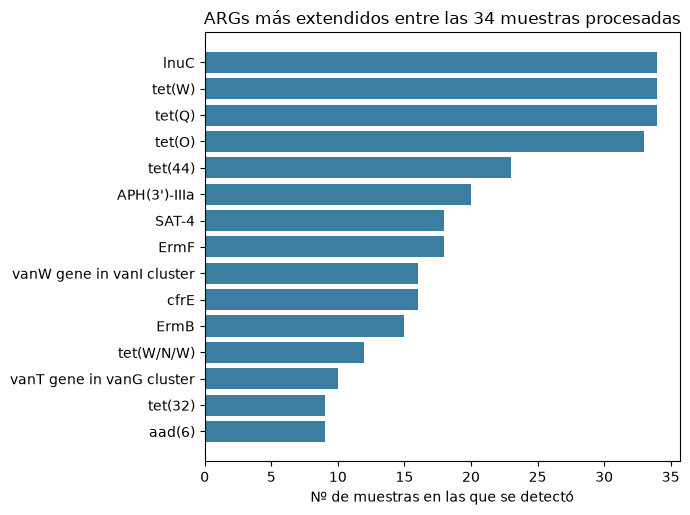

In [14]:
def cargar_resultados_disponibles():
    """Carga todos los rgi_<run>.txt ya completados en results/, leyendo de disco en vez de
    depender del estado en memoria de la celda de ejecucion (que puede seguir corriendo)."""
    filas = []
    for txt_path in sorted(Path("results").glob("*/rgi_*.txt")):
        run = txt_path.stem.replace("rgi_", "")
        if txt_path.stat().st_size == 0:
            continue
        df = pd.read_csv(txt_path, sep="\t")
        if df.empty:
            continue
        df.insert(0, "run", run)
        filas.append(df)
    return pd.concat(filas, ignore_index=True) if filas else pd.DataFrame()


resultados_disponibles = cargar_resultados_disponibles()
n_muestras = resultados_disponibles["run"].nunique() if not resultados_disponibles.empty else 0
print(f"Muestras con resultados completos: {n_muestras}")
print(f"Total de genes de resistencia detectados: {len(resultados_disponibles)}")

tabla_arg = (
    resultados_disponibles
    .groupby(["Best_Hit_ARO", "AMR Gene Family", "Drug Class"])
    .agg(n_detecciones=("run", "size"), n_muestras=("run", "nunique"))
    .sort_values(["n_muestras", "n_detecciones"], ascending=False)
    .reset_index()
)
display(tabla_arg)

top = tabla_arg.head(15).sort_values("n_muestras")
fig, ax = plt.subplots(figsize=(7, max(3, 0.35 * len(top))))
ax.barh(top["Best_Hit_ARO"], top["n_muestras"], color="#3B7EA1")
ax.set_xlabel("Nº de muestras en las que se detectó")
ax.set_title(f"ARGs más extendidos entre las {n_muestras} muestras procesadas")
plt.tight_layout()
plt.show()